# UC9 — Fundamentos Matemáticos e Primeiro Modelo de Machine Learning

## Do dado à aprendizagem

**Curso Técnico em Inteligência Artificial — SENAC**  
**Carga sugerida para este notebook:** 12 horas (4 encontros de 3h)

Este caderno foi pensado para acompanhar a primeira semana prática de Machine Learning.

A proposta é compreender **o que acontece por trás de um modelo** antes de utilizar algoritmos como uma caixa-preta.

---

## O que vamos estudar

### PARTE 1 — Como uma máquina aprende?
### PARTE 2 — Dados, features e target
### PARTE 3 — Nosso primeiro modelo
### PARTE 4 — Vetores e matrizes em Machine Learning
### PARTE 5 — Estatística aplicada
### PARTE 6 — Erro e função de custo
### PARTE 7 — Derivada e gradiente
### PARTE 8 — Treinamento e otimização
### PARTE 9 — Supervisionado × Não supervisionado × Reforço
### PARTE 10 — Desafio final

---

> **Ideia central da semana:** Machine Learning não é “mandar o computador pensar”. É criar um processo matemático capaz de ajustar parâmetros a partir de dados para representar padrões e realizar previsões ou decisões em novos exemplos.


# Como utilizar este notebook

O material alterna quatro tipos de bloco:

- **TEORIA** — conceito e interpretação;
- **DEMONSTRAÇÃO** — código executado com o professor;
- **EXPERIMENTO** — altere valores e observe o comportamento;
- **ATIVIDADE** — exercício que deve ser resolvido pelos alunos.

## Distribuição sugerida

| Aula | Partes | Foco |
|---|---|---|
| Aula 1 | 1, 2 e início da 3 | Como uma máquina aprende, features, target e primeiro modelo |
| Aula 2 | 3, 4 e 5 | Modelo, vetores, matrizes e estatística |
| Aula 3 | 6, 7 e 8 | Erro, custo, derivada, gradiente e otimização |
| Aula 4 / online | 9 e 10 | Tipos de aprendizado, revisão e desafio final |

Não é necessário concluir todas as atividades em sala. Algumas podem ser utilizadas como prática assíncrona.


## Bibliotecas utilizadas

Vamos trabalhar com:

- **NumPy** — vetores, matrizes e operações matemáticas;
- **Pandas** — organização e análise dos dados;
- **Matplotlib** — visualizações;
- **Scikit-learn** — modelos e ferramentas de Machine Learning.

Execute a célula abaixo apenas se o ambiente ainda não possuir essas bibliotecas.


In [ ]:
# Em Google Colab normalmente essas bibliotecas já estão instaladas.
# Descomente a linha abaixo apenas se necessário.

# !pip install -q numpy pandas matplotlib scikit-learn


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Ambiente preparado.")


Ambiente preparado.


# PARTE 1 — Como uma máquina aprende?

## 1.1 Programação tradicional × Machine Learning

Na programação tradicional, geralmente criamos regras explicitamente:

```text
DADOS + REGRAS PROGRAMADAS → RESULTADO
```

Exemplo:

```python

```



In [ ]:
renda = 1000

In [ ]:
if renda >= 10000:
    perfil = "alta renda"
else:
    perfil = "outro perfil"

A regra foi definida por uma pessoa.

Em Machine Learning, muitas vezes queremos descobrir uma relação que seria difícil escrever manualmente:

```text
DADOS + RESULTADOS CONHECIDOS → ALGORITMO DE APRENDIZAGEM → MODELO
```

Depois:

```text
NOVOS DADOS + MODELO → PREVISÃO
```

O modelo é uma representação matemática dos padrões identificados durante o treinamento.


## 1.2 Um problema imobiliário

Imagine que temos alguns imóveis com área e preço conhecidos:

| Área (m²) | Preço |
|---:|---:|
| 50 |  310.000 |
| 60 |  365.000 |
| 70 |  430.000 |
| 80 |  490.000 |

Queremos responder:

> **Quanto poderia valer um imóvel de 65 m²?**

Uma primeira tentativa poderia ser uma regra simples:

\[
preço = área 	x valor\_por\_m²
\]

Se escolhermos R$ 6.000 por m²:

\[
65 	x 6.000 = 390.000
\]

Mas de onde veio o valor **6.000**?

Essa é a pergunta fundamental: **como escolher parâmetros que funcionem bem para os dados?**


In [ ]:
areas_exemplo = np.array([40, 50, 60, 70, 80])
precos_exemplo = np.array([250000, 310000, 365000, 430000, 490000])

valor_m2 = 6000

previsoes = areas_exemplo * valor_m2

tabela = pd.DataFrame({
    "area_m2": areas_exemplo,
    "preco_real": precos_exemplo,
    "preco_previsto": previsoes,
    "erro": precos_exemplo - previsoes
})

tabela


,area_m2,preco_real,preco_previsto,erro
0,40,250000,240000,10000
1,50,310000,300000,10000
2,60,365000,360000,5000
3,70,430000,420000,10000
4,80,490000,480000,10000


## 1.3 O modelo faz tentativas

Nosso modelo provisório é:

\[$
\hat{y} = w \cdot x$
\]

onde:

- \(x\) = área do imóvel;
- \(w\) = parâmetro que representa um valor aproximado por m²;
- \(\hat{y}\) = preço previsto.

O símbolo \(\hat{y}\) é lido como **“y chapéu”** e normalmente representa a previsão.

Se o parâmetro \(w\) estiver ruim, as previsões terão erros grandes.

Treinar significa encontrar parâmetros melhores.


In [ ]:
def prever_preco_area(area, valor_m2):
    return area * valor_m2

In [ ]:
def prever_preco_area(area, valor_m2):
  preco_previsto = area * valor_m2
  return preco_previsto

In [ ]:
areas_teste = [40, 50, 60, 70, 80]

In [ ]:
valor = 6500

In [ ]:
for area in areas_teste:
  previsao = prever_preco_area(area, valor)
  print(f"Previsão para área {area} m²: R$ {previsao:,.2f}")

Previsão para área 40 m²: R$ 260,000.00
Previsão para área 50 m²: R$ 325,000.00
Previsão para área 60 m²: R$ 390,000.00
Previsão para área 70 m²: R$ 455,000.00
Previsão para área 80 m²: R$ 520,000.00


### EXPERIMENTO 1

Altere o valor abaixo.

Tente:

- 4.000
- 5.000
- 6.000
- 7.000
- 8.000

Observe como uma pequena alteração no parâmetro muda todas as previsões.


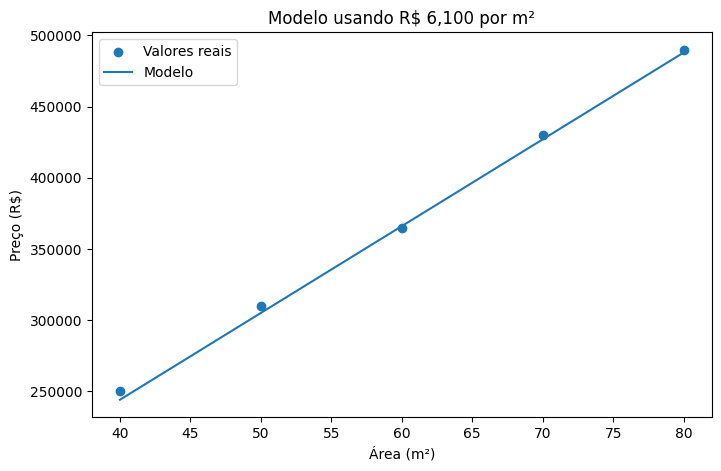

In [ ]:
valor_m2_teste = 6100 # ALTERE

previsoes_teste = areas_exemplo * valor_m2_teste

plt.figure(figsize=(8, 5))
plt.scatter(areas_exemplo, precos_exemplo, label="Valores reais")
plt.plot(areas_exemplo, previsoes_teste, label="Modelo")
plt.xlabel("Área (m²)")
plt.ylabel("Preço (R$)")
plt.title(f"Modelo usando R$ {valor_m2_teste:,.0f} por m²")
plt.legend()
plt.show()


## 1.4 A ideia de aprender

Um processo de aprendizagem pode ser resumido assim:

1. escolher parâmetros iniciais;
2. realizar previsões;
3. comparar as previsões com os valores corretos;
4. medir o erro;
5. alterar os parâmetros;
6. repetir o processo;
7. parar quando o modelo estiver suficientemente bom.

```text
PARÂMETROS
    ↓
PREVISÃO
    ↓
ERRO
    ↓
AJUSTE DOS PARÂMETROS
    ↓
NOVA PREVISÃO
```

Mais adiante construiremos esse ciclo manualmente.


### ATIVIDADE 1 — Pensando como um modelo

Sem utilizar Scikit-learn, responda:

1. Um modelo usando R\$ 4.000/m² tende a **subestimar** ou **superestimar** os imóveis da tabela?
2. E usando R\$ 8.000/m²?
3. Como poderíamos comparar matematicamente qual parâmetro é melhor?
4. Por que olhar apenas um imóvel não seria suficiente para escolher o parâmetro?

Registre suas respostas em uma célula Markdown abaixo.


# PARTE 2 — Dados, features e target

## 2.1 O conjunto de dados

Em Machine Learning, cada linha geralmente representa uma **observação** ou **amostra**.

No contexto imobiliário:

> Uma linha = um imóvel.

As colunas podem representar características desse imóvel.

Exemplos:

- área;
- quantidade de quartos;
- vagas;
- idade;
- bairro;


Quando uma variável é usada como informação de entrada para o modelo, ela é chamada de **feature**.

A variável que queremos prever é chamada de **target** ou variável-alvo.


## 2.2 Criando uma base imobiliária fictícia

Vamos gerar uma base sintética para a aula.

Ela não representa imóveis reais.

A vantagem de gerar nossa própria base é conhecer a lógica usada na criação e poder experimentar sem utilizar dados pessoais.


In [ ]:
rng = np.random.default_rng(RANDOM_STATE)

n = 250

area_m2 = rng.integers(30, 151, n)
quartos = np.clip(np.round(area_m2 / 28 + rng.normal(0, 0.7, n)), 1, 5).astype(int)
vagas = rng.integers(0, 4, n)
idade_anos = rng.integers(0, 35, n)

bairros = rng.choice(
    ["Águas Claras", "Taguatinga", "Asa Norte", "Samambaia"],
    size=n,
    p=[0.30, 0.25, 0.20, 0.25]
)

efeito_bairro = {
    "Águas Claras": 70000,
    "Taguatinga": 30000,
    "Asa Norte": 180000,
    "Samambaia": 0,
}

ruido = rng.normal(0, 35000, n)

preco = (
    90000
    + area_m2 * 4200
    + quartos * 18000
    + vagas * 25000
    - idade_anos * 1800
    + np.array([efeito_bairro[b] for b in bairros])
    + ruido
)

preco = np.maximum(preco, 120000).round(0)

df = pd.DataFrame({
    "area_m2": area_m2,
    "quartos": quartos,
    "vagas": vagas,
    "idade_anos": idade_anos,
    "bairro": bairros,
    "preco": preco,
})

df


,area_m2,quartos,vagas,idade_anos,bairro,preco
0,40,2,3,28,Asa Norte,499089.0
1,123,5,3,1,Samambaia,781580.0
2,109,4,1,2,Samambaia,656074.0
3,83,4,0,9,Asa Norte,606606.0
4,82,2,1,19,Samambaia,484530.0
...,...,...,...,...,...,...
245,40,2,0,1,Samambaia,331753.0
246,121,5,0,12,Taguatinga,718093.0
247,80,3,0,3,Águas Claras,565542.0
248,125,5,3,32,Taguatinga,770588.0


In [ ]:
df

,area_m2,quartos,vagas,idade_anos,bairro,preco
0,40,2,3,28,Asa Norte,499089.0
1,123,5,3,1,Samambaia,781580.0
2,109,4,1,2,Samambaia,656074.0
3,83,4,0,9,Asa Norte,606606.0
4,82,2,1,19,Samambaia,484530.0
...,...,...,...,...,...,...
245,40,2,0,1,Samambaia,331753.0
246,121,5,0,12,Taguatinga,718093.0
247,80,3,0,3,Águas Claras,565542.0
248,125,5,3,32,Taguatinga,770588.0


In [ ]:
#Quantidade de imóveis:
len(df)


250

In [ ]:
#Quantidade de colunas:
df.shape[1]

6

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area_m2     250 non-null    int64  
 1   quartos     250 non-null    int64  
 2   vagas       250 non-null    int64  
 3   idade_anos  250 non-null    int64  
 4   bairro      250 non-null    object 
 5   preco       250 non-null    float64
dtypes: float64(1), int64(4), object(1)
memory usage: 11.8+ KB


## 2.3 Features e target da nossa base

Inicialmente vamos utilizar apenas variáveis numéricas.

### Features

\[
$X =


### Target

\[
y = preço
\]

Em Python:


In [ ]:
features = ["area_m2", "quartos", "vagas" , "idade_anos"]

In [ ]:
X = df[features]
y = df["preco"]

In [ ]:
X

,area_m2,quartos,vagas,idade_anos
0,40,2,3,28
1,123,5,3,1
2,109,4,1,2
3,83,4,0,9
4,82,2,1,19
...,...,...,...,...
245,40,2,0,1
246,121,5,0,12
247,80,3,0,3
248,125,5,3,32


In [ ]:
y

,preco
0,499089.0
1,781580.0
2,656074.0
3,606606.0
4,484530.0
...,...
245,331753.0
246,718093.0
247,565542.0
248,770588.0


In [ ]:
X.shape

(250, 4)

## 2.4 Por que o bairro ficou de fora?

O bairro também é uma informação importante, mas é uma variável **categórica**:

```text
Águas Claras
Taguatinga
Asa Norte
Samambaia
```

Muitos algoritmos não recebem essas palavras diretamente.

Na próxima semana estudaremos formas de transformar categorias em informações numéricas, como **One-Hot Encoding**.

Por enquanto, nosso primeiro modelo utilizará somente as features numéricas.


### ATIVIDADE 2 — Identifique X e y

Para cada problema, identifique possíveis **features** e o **target**:

#### Caso A
Prever se um cliente desistirá de uma compra.

#### Caso B
Prever o tempo de venda de um imóvel.

#### Caso C
Prever a nota de um aluno.

#### Caso D
Detectar se uma transação é fraude.

Discuta também:

> Toda coluna existente em uma base deveria automaticamente ser utilizada como feature?


# PARTE 3 — Nosso primeiro modelo

## 3.1 Antes do modelo: precisamos separar os dados

Um erro comum é treinar e avaliar o modelo usando exatamente os mesmos dados.

Isso seria parecido com:

> entregar a prova ao aluno antes da avaliação e depois concluir que ele aprendeu porque acertou as respostas.

Precisamos reservar dados que o modelo **não utilizará durante o treinamento**.

```text
BASE COMPLETA
     ↓
 ┌───────────────┐
 │ TREINO        │ → modelo aprende
 │ TESTE         │ → avaliação final
 └───────────────┘
```


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, #dados de entrada -> features
    y, #dados de saida (queremos prever) -> Target
    test_size=0.2, #Estamos pegando 20% da base para teste.
    random_state=RANDOM_STATE
)

In [ ]:
X_train.shape

(200, 4)

In [ ]:
X_test.shape

(50, 4)

## 3.2 Baseline: antes de criar um modelo inteligente

Sempre é útil ter uma solução simples para comparação.

Uma baseline possível para preço de imóveis:

> prever para todos os imóveis o preço médio observado no conjunto de treinamento.

Se nosso modelo sofisticado não superar essa estratégia ingênua, temos um problema.


In [ ]:
preco_medio_treino = y_train.mean()

In [ ]:
preco_medio_treino

np.float64(600457.29)

In [ ]:
print(f'Preço médio de treino: {preco_medio_treino:,.2f}')

Preço médio de treino: 600,457.29


In [ ]:
baseline_pred = np.full(
    shape=len(y_test),
    fill_value=preco_medio_treino
)

In [ ]:
baseline_pred

array([600457.29, 600457.29, 600457.29, 600457.29, 600457.29, 600457.29,
       600457.29, 600457.29, 600457.29, 600457.29, 600457.29, 600457.29,
       600457.29, 600457.29, 600457.29, 600457.29, 600457.29, 600457.29,
       600457.29, 600457.29, 600457.29, 600457.29, 600457.29, 600457.29,
       600457.29, 600457.29, 600457.29, 600457.29, 600457.29, 600457.29,
       600457.29, 600457.29, 600457.29, 600457.29, 600457.29, 600457.29,
       600457.29, 600457.29, 600457.29, 600457.29, 600457.29, 600457.29,
       600457.29, 600457.29, 600457.29, 600457.29, 600457.29, 600457.29,
       600457.29, 600457.29])

In [ ]:
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_mae

164501.0664

## 3.3 LinearRegression

Agora utilizaremos um algoritmo pronto do Scikit-learn.

A regressão linear busca uma relação aproximadamente linear entre as features e o target.

Com várias features, podemos representar a previsão como:

\[
$\hat{y} = w_1x_1 + w_2x_2 + ... + w_nx_n + b$
\]

onde:

- \(x_i\) são as features;
- \(w_i\) são os coeficientes aprendidos;
- \(b\) é o intercepto;
- \(\hat{y}\) é a previsão.

O método `.fit()` realiza o ajuste dos parâmetros.


In [ ]:
#Carregando o modelo
modelo = LinearRegression()

In [ ]:
#Treinando o modelo:
modelo.fit(X_train, y_train)

LinearRegression()

## 3.4 O que o modelo aprendeu?

O modelo possui parâmetros depois do treinamento.

Vamos inspecioná-los.


In [ ]:
modelo.coef_

array([ 4363.2803188 , 15924.60537093, 24055.25804577, -2385.65718137])

In [ ]:
coeficentes = pd.DataFrame({
    "feature": features,
    "coeficiente": modelo.coef_
})
coeficentes


,feature,coeficiente
0,area_m2,4363.280319
1,quartos,15924.605371
2,vagas,24055.258046
3,idade_anos,-2385.657181


In [ ]:
modelo.intercept_

np.float64(158727.47385053313)

### Como interpretar um coeficiente?

Mantendo as demais variáveis constantes, um coeficiente positivo indica que valores maiores daquela feature tendem a aumentar a previsão.

Exemplo hipotético:

```text
coeficiente_area = 4.100
```

Isso significa que, segundo o modelo, um aumento de aproximadamente 1 m² está associado a um aumento estimado de cerca de R$ 4.100 no preço, **mantidas as demais features constantes**.

Cuidado: coeficiente não significa necessariamente causalidade.


## 3.5 Realizando previsões


In [ ]:
#Prevendo os valores de teste e armazenando em uma variável
y_pred = modelo.predict(X_test)



In [ ]:
#comparando os valores previstos com os valores reais:
comparacao = pd.DataFrame({
    "real": y_test,
    "previsto": y_pred.round(2)
})
comparacao

,real,previsto
142,462841.0,529498.47
6,339920.0,380792.89
97,715514.0,706341.98
60,1055113.0,909039.20
112,480423.0,570098.05
181,536315.0,374169.28
197,485438.0,361288.79
184,798309.0,661452.70
9,325927.0,345614.61
104,809281.0,790906.85


In [ ]:
comparacao["erro"] = comparacao["real"] - comparacao["previsto"]
comparacao

,real,previsto,erro
142,462841.0,529498.47,-66657.47
6,339920.0,380792.89,-40872.89
97,715514.0,706341.98,9172.02
60,1055113.0,909039.20,146073.80
112,480423.0,570098.05,-89675.05
181,536315.0,374169.28,162145.72
197,485438.0,361288.79,124149.21
184,798309.0,661452.70,136856.30
9,325927.0,345614.61,-19687.61
104,809281.0,790906.85,18374.15


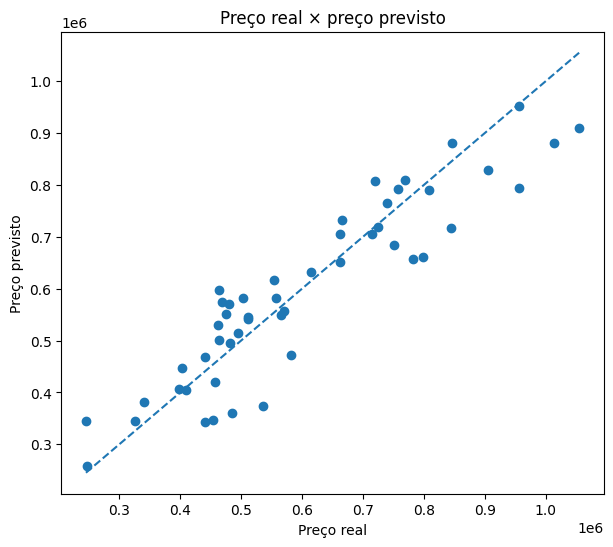

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred)
limites = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]
plt.plot(limites, limites, linestyle="--")
plt.xlabel("Preço real")
plt.ylabel("Preço previsto")
plt.title("Preço real × preço previsto")
plt.show()


## 3.6 Primeira avaliação

Vamos utilizar algumas métricas apenas de forma intuitiva neste momento.

### MAE — Mean Absolute Error
Média dos erros absolutos.

É fácil de interpretar porque permanece na unidade do target.

### MSE — Mean Squared Error
Eleva os erros ao quadrado antes da média.

Erros grandes recebem peso maior.

### RMSE
Raiz quadrada do MSE.

Volta para a unidade original.

### R²
Indica o quanto da variação do target é explicada pelo modelo, em relação a uma referência baseada na média.

Estudaremos métricas com mais profundidade posteriormente.


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


In [ ]:
print(f"MAE: {mae:,.2f}")
print(f"MSE: {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²: {r2:,.2f}")

MAE: 61,392.52
MSE: 5,988,208,649.51
RMSE: 77,383.52
R²: 0.84


### ATIVIDADE 3 — Interprete o primeiro modelo

Responda:

1. O modelo superou a baseline?
2. Qual foi aproximadamente o erro absoluto médio?
3. O modelo acertou exatamente todos os preços?
4. Isso significa que o modelo “falhou”?
5. Que informação importante da base não utilizamos?
6. Por que não deveríamos avaliar um modelo apenas olhando cinco previsões?


## 3.7 Fazendo uma previsão de um novo imóvel

Suponha:

- área: 75 m²;
- 2 quartos;
- 1 vaga;
- 5 anos de idade.


In [ ]:
novo_imovel = pd.DataFrame([{
    "area_m2": 75,
    "quartos": 2,
    "vagas": 1,
    "idade_anos": 5
}])

In [ ]:
novo_imovel

,area_m2,quartos,vagas,idade_anos
0,75,2,1,5


In [ ]:
previsao_novo = modelo.predict(novo_imovel)

In [ ]:
previsao_novo

array([529949.68064118])

In [ ]:
print(f"O valor do imóvel é: {previsao_novo[0]:,.2f}")

O valor do imóvel é: 529,949.68


In [ ]:
df

,area_m2,quartos,vagas,idade_anos,bairro,preco
0,40,2,3,28,Asa Norte,499089.0
1,123,5,3,1,Samambaia,781580.0
2,109,4,1,2,Samambaia,656074.0
3,83,4,0,9,Asa Norte,606606.0
4,82,2,1,19,Samambaia,484530.0
...,...,...,...,...,...,...
245,40,2,0,1,Samambaia,331753.0
246,121,5,0,12,Taguatinga,718093.0
247,80,3,0,3,Águas Claras,565542.0
248,125,5,3,32,Taguatinga,770588.0


### Reflexão

O modelo produziu um número, mas ainda não sabe:

- em qual bairro está o imóvel;
- estado de conservação;
- andar;
- posição solar;
- padrão de acabamento;
- condomínio;
- proximidade de transporte;
- situação do mercado.

**Machine Learning não cria informação que não existe nos dados.**

A qualidade de um modelo depende fortemente das informações disponibilizadas e da qualidade do conjunto de dados.


# PARTE 4 — Vetores e matrizes em Machine Learning

## 4.1 Por que Álgebra Linear?

Machine Learning trabalha constantemente com conjuntos de números.

Um imóvel:

```text
Área = 75
Quartos = 2
Vagas = 1
Idade = 5
```

pode ser representado por um vetor:

\[
$x = [75,\ 2,\ 1,\ 5]$
\]

Muitos imóveis formam uma matriz:

\[$\
X =
\begin{bmatrix}
75 & 2 & 1 & 5 \\
60 & 2 & 1 & 10 \\
100 & 3 & 2 & 4
\end{bmatrix}
$\]

Em Machine Learning:

- linhas → amostras;
- colunas → features.


In [ ]:
vetor_imovel = np.array([75, 2, 1, 5])

In [ ]:
vetor_imovel

array([75,  2,  1,  5])

In [ ]:
x = [75, 2, 1, 5]

In [ ]:
x

[75, 2, 1, 5]

In [ ]:
print(vetor_imovel)

[75  2  1  5]


In [ ]:
#Exibir as dimensões:
vetor_imovel.ndim

1

In [ ]:
#Mostrando o tamanho do vetor:
vetor_imovel.shape

(4,)

### Construindo matriz

In [ ]:
matriz_imoveis = X.head(5).to_numpy()

In [ ]:
matriz_imoveis

array([[ 40,   2,   3,  28],
       [123,   5,   3,   1],
       [109,   4,   1,   2],
       [ 83,   4,   0,   9],
       [ 82,   2,   1,  19]])

In [ ]:
print(matriz_imoveis)

[[ 40   2   3  28]
 [123   5   3   1]
 [109   4   1   2]
 [ 83   4   0   9]
 [ 82   2   1  19]]


In [ ]:
matriz_imoveis.shape

(5, 4)

In [ ]:
matriz_imoveis.ndim

2

## 4.2 O significado de `shape`

Se:

```python
X.shape == (250, 4)
```

significa:

- 250 amostras;
- 4 features.

Esse formato aparecerá constantemente durante o curso.

Algoritmos normalmente esperam uma matriz de features no formato:

```text
(n_amostras, n_features)
```


## 4.3 Produto escalar e uma previsão linear

Considere:


$x = [75,\ 2,\ 1,\ 5]$


e pesos:


$w = [4200,\ 18000,\ 25000,\ -1800]$


O modelo calcula:

\[$
x \cdot w
\$]

que significa:

$
75(4200) + 2(18000) + 1(25000) + 5(-1800)
$

Depois pode somar um intercepto \(b\).


In [ ]:
print(modelo.intercept_)

158727.47385053313


In [ ]:
x = np.array([75, 2, 1, 5])
w = np.array([4200, 18000, 25000, -1800])
b = 160000


In [ ]:
produto_escalar = np.dot(x, w)

In [ ]:
produto_escalar

np.int64(367000)

In [ ]:
previsao = produto_escalar + b

In [ ]:
previsao

np.int64(527000)

In [ ]:
print(f"A previsão manual foi de: R$ {previsao:,.2f}")

A previsão manual foi de: R$ 527,000.00


## 4.4 Uma linha de código, várias multiplicações

Ao executar:

```python
X @ w
```

a multiplicação matricial calcula previsões para várias linhas de uma única vez.

Esse tipo de operação é uma das razões pelas quais NumPy é tão importante em Ciência de Dados.


In [ ]:
matriz_imoveis

array([[ 40,   2,   3,  28],
       [123,   5,   3,   1],
       [109,   4,   1,   2],
       [ 83,   4,   0,   9],
       [ 82,   2,   1,  19]])

In [ ]:
w

array([ 4200, 18000, 25000, -1800])

In [ ]:
previsoes_vetorizadas = matriz_imoveis @ w + b

In [ ]:
previsoes_vetorizadas

array([388600, 839800, 711200, 564400, 531200])

In [ ]:
X @ w + b

,0
0,388600
1,839800
2,711200
3,564400
4,531200
...,...
245,362200
246,736600
247,544600
248,792400


### ATIVIDADE 4 — Álgebra Linear aplicada

Considere:

```python
x = [80, 3, 2, 10]
w = [4000, 15000, 20000, -1000]
b = 100000
```

1. Calcule manualmente a previsão.
2. Faça o mesmo com `np.dot`.
3. Explique o significado de cada posição do vetor.
4. O que aconteceria se `x` tivesse 4 valores e `w` tivesse 3?


In [ ]:
# RESOLVA AQUI

x_atividade = np.array([80, 3, 2, 10])
w_atividade = np.array([4000, 15000, 20000, -1000])
b_atividade = 100000

# previsao =

previsao_exercicio = np.dot(x_atividade, w_atividade) + b_atividade
print(previsao_exercicio)

495000


In [ ]:
# RESOLVA AQUI

x_atividade = np.array([80, 3, 2, 10])
w_atividade = np.array([4000, 15000, 20000, 2])
b_atividade = 100000

# previsao =

previsao_exercicio = np.dot(x_atividade, w_atividade) + b_atividade
print(previsao_exercicio)

505020


In [ ]:
w_atividade.shape

(4,)

In [ ]:
x_atividade.shape

(4,)

In [ ]:
X.shape

(250, 4)

In [ ]:
w

array([ 4200, 18000, 25000, -1800])

In [ ]:
w.shape

(4,)

# PARTE 5 — Estatística aplicada

## 5.1 Por que Estatística?

Antes de modelar, precisamos compreender os dados.

Perguntas importantes:

- qual é o valor típico?
- quanto os valores variam?
- existem valores extremos?
- as variáveis parecem relacionadas?
- existem grupos ou assimetrias?

A Estatística nos dá ferramentas para resumir e investigar o conjunto de dados.


In [ ]:
df

,area_m2,quartos,vagas,idade_anos,bairro,preco
0,40,2,3,28,Asa Norte,499089.0
1,123,5,3,1,Samambaia,781580.0
2,109,4,1,2,Samambaia,656074.0
3,83,4,0,9,Asa Norte,606606.0
4,82,2,1,19,Samambaia,484530.0
...,...,...,...,...,...,...
245,40,2,0,1,Samambaia,331753.0
246,121,5,0,12,Taguatinga,718093.0
247,80,3,0,3,Águas Claras,565542.0
248,125,5,3,32,Taguatinga,770588.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area_m2     250 non-null    int64  
 1   quartos     250 non-null    int64  
 2   vagas       250 non-null    int64  
 3   idade_anos  250 non-null    int64  
 4   bairro      250 non-null    object 
 5   preco       250 non-null    float64
dtypes: float64(1), int64(4), object(1)
memory usage: 11.8+ KB


In [ ]:
df.describe()

,area_m2,quartos,vagas,idade_anos,preco
count,250.000000,250.00000,250.000000,250.000000,2.500000e+02
mean,90.812000,3.21600,1.476000,17.724000,6.006918e+05
std,33.049687,1.26163,1.134271,10.143143,1.819822e+05
min,30.000000,1.00000,0.000000,0.000000,1.900930e+05
25%,63.250000,2.00000,0.000000,10.000000,4.696582e+05
50%,90.000000,3.00000,2.000000,18.000000,6.042915e+05
75%,119.750000,4.00000,2.000000,26.000000,7.439312e+05
max,150.000000,5.00000,3.000000,34.000000,1.055113e+06


## 5.2 Média × mediana

### Média

\[
bar{x} = $\frac{x_1 + x_2 + ... + x_n}{n}$
\]

### Mediana

Valor central depois de ordenar os dados.

A média é bastante influenciada por valores extremos.

A mediana geralmente é mais resistente a esses valores.


In [ ]:
media_preco = df["preco"].mean()
mediana_preco = df["preco"].median()

print(f"Média: R$ {media_preco:,.2f}")
print(f"Mediana: R$ {mediana_preco:,.2f}")


Média: R$ 600,691.77
Mediana: R$ 604,291.50


## 5.3 Demonstrando o efeito de um outlier


In [ ]:
precos_simples = np.array([300000, 200000, 500000, 340000, 430000])


In [ ]:
precos_simples.mean()

np.float64(354000.0)

In [ ]:
np.median(precos_simples)

np.float64(340000.0)

### com autlier

In [ ]:
precos_simples2 = np.array([300000, 200000, 500000, 340000, 430000, 10000000])

In [ ]:
precos_simples2.mean()

np.float64(1961666.6666666667)

In [ ]:
np.median(precos_simples2)

np.float64(385000.0)

## 5.4 Variância e desvio padrão

A média não informa o quanto os dados estão espalhados.

Duas regiões podem ter a mesma média de preço, mas comportamentos completamente diferentes.

O **desvio padrão** ajuda a medir a dispersão.

Quanto maior o desvio padrão, maior tende a ser a variabilidade em torno da média.


In [ ]:
df["area_m2"].std()

33.04968658145687

In [ ]:
df["preco"].std()

181982.18034807954

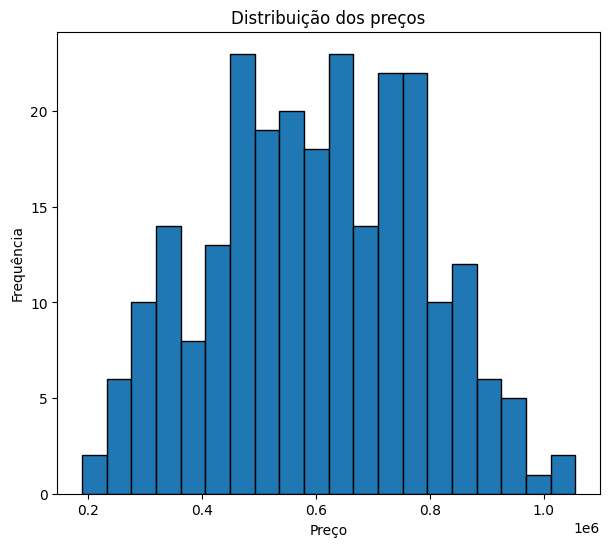

In [ ]:
plt.figure(figsize=(7, 6))
plt.hist(df["preco"], bins=20, edgecolor="black")
plt.xlabel("Preço")
plt.ylabel("Frequência")
plt.title("Distribuição dos preços")
plt.show()

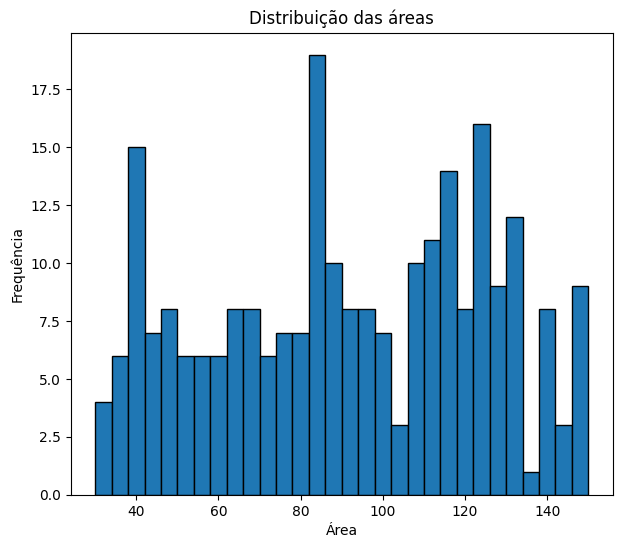

In [ ]:
plt.figure(figsize=(7, 6))
plt.hist(df["area_m2"], bins=30, edgecolor="black")
plt.xlabel("Área")
plt.ylabel("Frequência")
plt.title("Distribuição das áreas")
plt.show()

## 5.5 Quartis e boxplot

Quartis dividem os dados ordenados em regiões.

- Q1 → aproximadamente 25% abaixo;
- Q2 → mediana;
- Q3 → aproximadamente 75% abaixo.

O boxplot é uma representação útil para observar:

- posição central;
- dispersão;
- assimetria;
- possíveis valores extremos.


In [ ]:
df["preco"].quantile([0.25, 0.5, 0.75])


,preco
0.25,469658.25
0.50,604291.50
0.75,743931.25


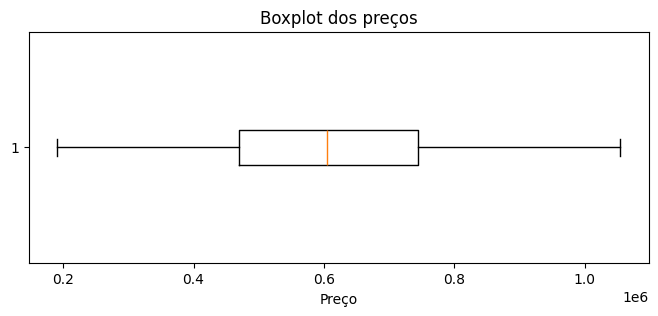

In [ ]:
plt.figure(figsize=(8, 3))
plt.boxplot(df["preco"], vert=False)
plt.xlabel("Preço")
plt.title("Boxplot dos preços")
plt.show()

## 5.6 Correlação

Correlação mede a intensidade e direção de uma relação linear entre duas variáveis.

O coeficiente de Pearson varia, em geral, entre:

\[
$-1 \leq r \leq 1$
\]

- próximo de +1 → relação linear positiva forte;
- próximo de -1 → relação linear negativa forte;
- próximo de 0 → pouca relação linear.

**Correlação não implica causalidade.**


In [ ]:
colunas_numericas = ["area_m2", "quartos", "vagas", "idade_anos", "preco"]


In [ ]:
correlacoes = df[colunas_numericas].corr()

In [ ]:
correlacoes

,area_m2,quartos,vagas,idade_anos,preco
area_m2,1.000000,0.849624,0.046106,0.032143,0.895374
quartos,0.849624,1.000000,0.037314,0.018800,0.799591
vagas,0.046106,0.037314,1.000000,-0.069170,0.218189
idade_anos,0.032143,0.018800,-0.069170,1.000000,-0.093523
preco,0.895374,0.799591,0.218189,-0.093523,1.000000


In [ ]:
import seaborn as sns

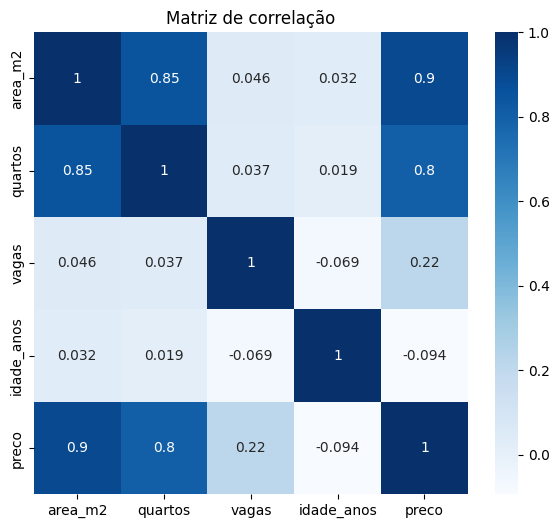

In [ ]:
plt.figure(figsize=(7, 6))
sns.heatmap(correlacoes, annot=True, cmap="Blues")
plt.title("Matriz de correlação")
plt.show()

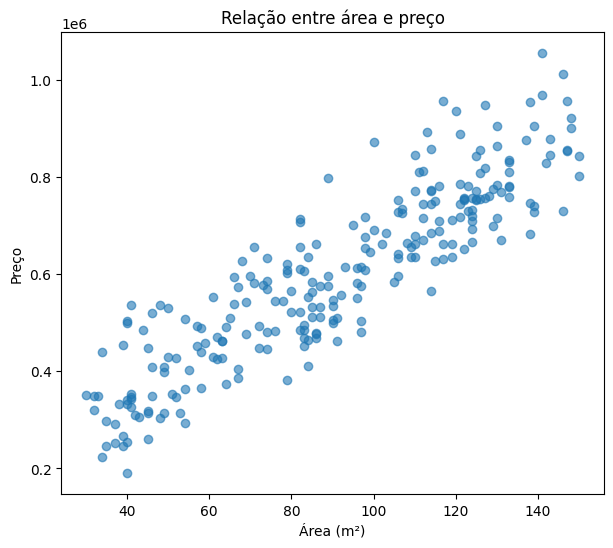

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(df["area_m2"], df["preco"], alpha=0.6)
plt.xlabel("Área (m²)")
plt.ylabel("Preço")
plt.title("Relação entre área e preço")
plt.show()

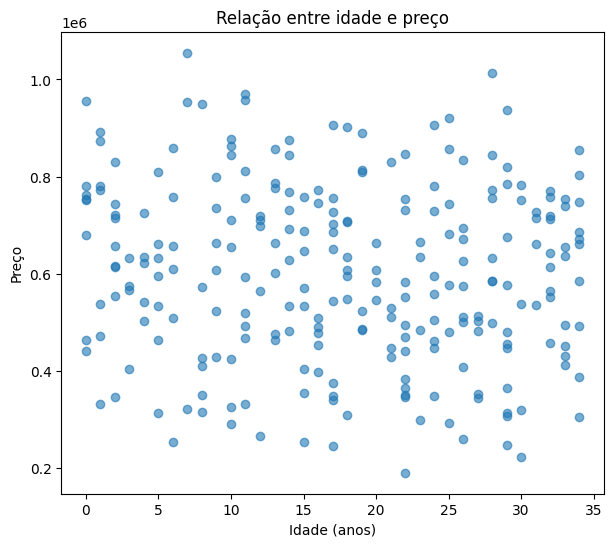

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(df["idade_anos"], df["preco"], alpha=0.6)
plt.xlabel("Idade (anos)")
plt.ylabel("Preço")
plt.title("Relação entre idade e preço")
plt.show()

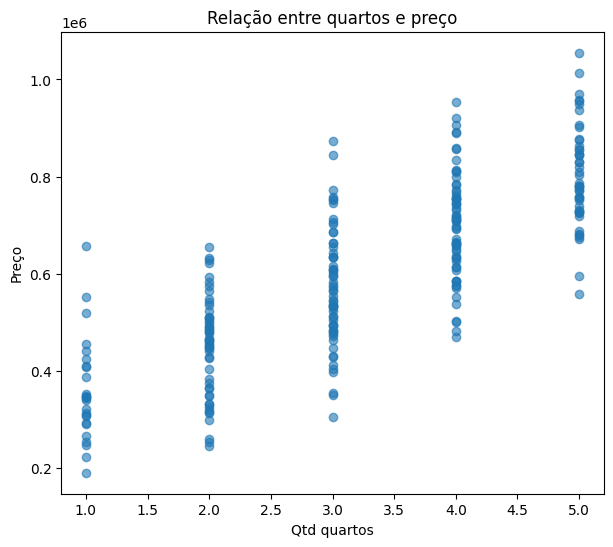

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(df["quartos"], df["preco"], alpha=0.6)
plt.xlabel("Qtd quartos")
plt.ylabel("Preço")
plt.title("Relação entre quartos e preço")
plt.show()

### ATIVIDADE 5 — Estatística da base

Responda com código:

1. Qual é a média da área?
2. Qual é a mediana do preço?
3. Qual feature numérica tem maior correlação positiva com o preço?
4. Qual feature tem correlação negativa com o preço?
5. Compare média de preço por bairro.
6. A correlação observada prova que uma variável causa a outra?


In [ ]:
# RESOLVA AQUI

# Dica:
df.groupby("bairro")["preco"].mean().sort_values(ascending=False)


,preco
bairro,
Asa Norte,718011.884615
Águas Claras,611129.756410
Taguatinga,570122.800000
Samambaia,516013.933333


# PARTE 6 — Erro e função de custo

## 6.1 Resíduo

Para cada observação:

\[
erro = y - \hat{y}
\]

onde:

- \(y\) = valor real;
- \(\hat{y}\) = valor previsto.

Esse erro individual também é chamado de **resíduo** em muitos contextos de regressão.


In [ ]:
comparacao


,real,previsto,erro
142,462841.0,529498.47,-66657.47
6,339920.0,380792.89,-40872.89
97,715514.0,706341.98,9172.02
60,1055113.0,909039.20,146073.80
112,480423.0,570098.05,-89675.05
181,536315.0,374169.28,162145.72
197,485438.0,361288.79,124149.21
184,798309.0,661452.70,136856.30
9,325927.0,345614.61,-19687.61
104,809281.0,790906.85,18374.15


## 6.2 Por que não usar a soma simples dos erros?

Imagine:

```text
Erro do imóvel A = +50.000
Erro do imóvel B = -50.000
```

A soma seria zero.

Isso não significa que o modelo acertou.

Precisamos de uma medida que evite o cancelamento dos sinais.


## 6.3 MAE

\[
$MAE = \frac{1}{n}\sum |y_i - \hat{y_i}|$
\]

Transformamos cada erro em valor absoluto antes de calcular a média.

Vantagem: interpretação simples.

> “Em média, o modelo erra aproximadamente X reais.”


## 6.4 MSE

\[
$MSE = \frac{1}{n}\sum(y_i - \hat{y_i})^2$
\]

Ao elevar o erro ao quadrado:

- sinais deixam de se cancelar;
- erros grandes passam a ter impacto maior;
- a função possui propriedades matemáticas muito úteis para otimização.


In [ ]:
exemplos_erros = np.array([10000, -20000, 50000])


In [ ]:
mae_manual = np.mean(np.abs(exemplos_erros))
mse_manual = np.mean(exemplos_erros ** 2)
rmse_manual = np.sqrt(mse_manual)

print(f"MAE manual: {mae_manual:,.2f}")
print(f"MSE manual: {mse_manual:,.2f}")
print(f"RMSE manual: {rmse_manual:,.2f}")

MAE manual: 26,666.67
MSE manual: 1,000,000,000.00
RMSE manual: 31,622.78


## 6.5 Função de custo

Uma **função de custo** resume o quão ruins estão os parâmetros do modelo.

Imagine nosso modelo simplificado:

\[
$\hat{y} = w \cdot área$
\]

Para cada valor de \(w\), podemos calcular o MSE.

Nosso objetivo passa a ser:

> encontrar o valor de \(w\) que minimiza o custo.


In [ ]:
areas_exemplo = np.array([40, 50, 60, 70, 80])
precos_exemplo = np.array([250000, 310000, 365000, 430000, 490000])

In [ ]:
def mse_para_area(valor_m2):
  previsoes = areas_exemplo * valor_m2
  return np.mean((precos_exemplo - previsoes)**2)


In [ ]:
valores_m2 = np.linspace(3000, 9000, 200)
custos = np.array([mse_para_area(m2) for m2 in valores_m2])

melhor_indice = np.argmin(custos)
melhor_valor_m2 = valores_m2[melhor_indice]
melhor_custo = custos[melhor_indice]

print(f"Melhor valor de m2: {melhor_valor_m2:,.2f}")
print(f"Melhor custo: {melhor_custo:,.2f}")


Melhor valor de m2: 6,135.68
Melhor custo: 8,420,115.65


In [ ]:
rmses = np.sqrt(melhor_custo)
rmses

np.float64(2901.743554080057)

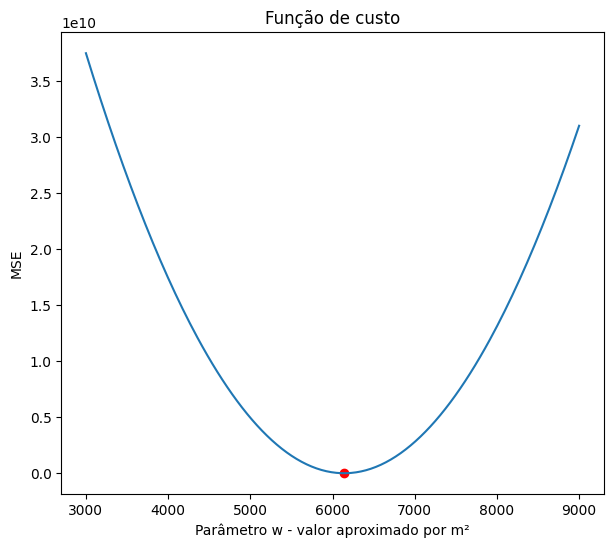

In [ ]:
plt.figure(figsize=(7, 6))
plt.plot(valores_m2, custos)
plt.scatter(melhor_valor_m2, melhor_custo, color="red")
#plt.axhline(0, color='black', linewidth=1.2)
plt.xlabel("Parâmetro w - valor aproximado por m²")
plt.ylabel("MSE")
plt.title("Função de custo")
plt.show()

### Interpretação

O gráfico acima é extremamente importante.

Cada ponto representa:

```text
um valor de w
      ↓
várias previsões
      ↓
um MSE
```

Queremos caminhar para o ponto em que o custo é menor.

Essa ideia é a base de diversos processos de otimização em Machine Learning.


### ATIVIDADE 6 — Investigando a função de custo

1. Calcule o MSE para:
   - w = 4.000
   - w = 5.000
   - w = 6.000
   - w = 7.000
   - w = 8.000
2. Qual foi o melhor?
3. O melhor desses cinco é necessariamente o melhor valor possível?
4. Como poderíamos encontrar um valor melhor sem testar infinitas possibilidades?


In [ ]:
# RESOLVA AQUI

for w_teste in [4000, 5000, 6000, 7000, 8000]:
    custo = mse_para_area(w_teste)
    print(f"w = {w_teste} → MSE = {custo:,.2f}")




w = 4000 → MSE = 17,445,000,000.00
w = 5000 → MSE = 4,965,000,000.00
w = 6000 → MSE = 85,000,000.00
w = 7000 → MSE = 2,805,000,000.00
w = 8000 → MSE = 13,125,000,000.00


# PARTE 7 — Derivada e gradiente

## 7.1 Por que derivada aparece em Machine Learning?

A função de custo responde:

> **Quão ruim está meu modelo?**

A derivada ajuda a responder:

> **Se eu alterar um parâmetro um pouco, para que lado o custo muda?**

De forma intuitiva, a derivada representa uma **taxa de variação** ou inclinação local.


## 7.2 Uma analogia

Imagine que estamos em uma montanha coberta por neblina.

Nosso objetivo é chegar ao ponto mais baixo.

Não conseguimos enxergar toda a montanha, mas conseguimos sentir a inclinação do terreno.

- inclinação positiva → um lado sobe;
- inclinação negativa → o outro lado sobe;
- inclinação próxima de zero → podemos estar perto de um ponto mínimo.

O gradiente usa essa informação para orientar a atualização dos parâmetros.


## 7.3 Derivada numérica

Podemos aproximar uma derivada utilizando uma pequena variação:

$ f'(x) \approx \frac{f(x+h)-f(x-h)}{2h} $


Não é necessário memorizar essa expressão nesta aula.

Queremos compreender a interpretação.


In [ ]:
def derivada_numerica(funcao, x, h=0.01):
  return (funcao(x+h) - funcao(x-h)) / (2 * h)

In [ ]:
for w_teste in [4000, 5000, 6000, 7000, 8000]:
    grad = derivada_numerica(mse_para_area, w_teste)
    print(f"w = {w_teste} → gradiente = {grad:,.2f}")

w = 4000 → gradiente = -16,280,000.00
w = 5000 → gradiente = -8,680,000.00
w = 6000 → gradiente = -1,080,000.00
w = 7000 → gradiente = 6,520,000.00
w = 8000 → gradiente = 14,120,000.00


### Como interpretar o sinal?

Se a derivada no ponto atual for negativa, aumentar o parâmetro pode reduzir o custo.

Se for positiva, diminuir o parâmetro pode reduzir o custo.

Por isso uma atualização típica possui a forma:


$w_{novo} = w_{atual} - \alpha \cdot gradiente$


O símbolo \(lpha\) representa a **taxa de aprendizagem** (*learning rate*).


## 7.4 Gradiente

Quando temos apenas um parâmetro, falamos naturalmente em derivada.

Quando o modelo possui vários parâmetros:

\[
w_1, w_2, w_3, ...
\]

precisamos observar a direção de mudança em relação a todos eles.

O vetor que reúne essas derivadas parciais é chamado de **gradiente**.

```text
gradiente =
[
  mudança do custo em relação a w1,
  mudança do custo em relação a w2,
  mudança do custo em relação a w3
]
```

É por isso que vetores, matrizes, derivadas e Machine Learning aparecem juntos.


### ATIVIDADE 7 — Interpretação do gradiente

Sem fazer contas avançadas, responda:

1. Se a derivada do custo em relação a `w` é positiva, por que subtraímos o gradiente?
2. O que esperamos encontrar quando a derivada se aproxima de zero?
3. Uma derivada próxima de zero garante sempre o melhor ponto global?
4. O que muda quando temos 100 parâmetros em vez de apenas um?


# PARTE 8 — Treinamento e otimização

## 8.1 Gradient Descent

Vamos finalmente fazer o computador alterar um parâmetro automaticamente.

Algoritmo simplificado:

```text
1. Escolha w inicial
2. Calcule o custo
3. Calcule o gradiente
4. Atualize w
5. Repita
```

Essa técnica é chamada de **Gradient Descent** ou descida do gradiente.


## 8.2 Importante: escala dos valores

Nossos preços estão em centenas de milhares, enquanto a área está entre dezenas e centenas.

Para tornar o exemplo numérico mais estável e fácil de visualizar, vamos trabalhar inicialmente com:

- área dividida por 100;
- preço dividido por 100.000.

Isso é uma forma didática de reescala.

Mais adiante estudaremos técnicas formais de padronização e normalização.


## 8.3 O que é uma época?

Uma **época** representa uma passagem de treinamento sobre o conjunto de exemplos, dependendo do algoritmo e da forma de atualização utilizada.

No nosso exemplo simplificado:

```text
Época 1
calcula erro → atualiza w

Época 2
calcula erro → atualiza w

...

Época 100
```

O modelo não “entendeu” os imóveis.

Ele ajustou matematicamente o parâmetro para reduzir a função de custo.


## 8.4 Learning rate

A taxa de aprendizagem controla o tamanho do passo.

### Muito pequena

```text
w → 5.00
w → 5.01
w → 5.02
...
```

Pode demorar muito.

### Adequada

Converge em uma quantidade razoável de passos.

### Muito grande

Pode ultrapassar repetidamente o mínimo ou até divergir.

Vamos experimentar.


### ATIVIDADE 8 — Quebre o treinamento

Experimente taxas diferentes:

```text
0.001
0.01
0.1
0.5
1
2
5
```

Para cada uma, observe:

- o custo cai?
- cai lentamente?
- oscila?
- explode?
- aparece `inf` ou valores enormes?

Depois responda:

> Por que a taxa de aprendizagem é chamada de **hiperparâmetro**, enquanto `w` é um parâmetro aprendido?


## 8.5 Comparando com o Scikit-learn

Quando executamos:

```python
modelo.fit(X_train, y_train)
```

o algoritmo faz o processo de ajuste por nós.

Nem todo algoritmo do Scikit-learn usa Gradient Descent internamente. A `LinearRegression`, por exemplo, resolve o problema de mínimos quadrados por métodos apropriados à regressão linear.

O objetivo do nosso Gradient Descent manual foi compreender a lógica geral:

> **definir uma função de custo e ajustar parâmetros para melhorar o modelo.**


## 8.6 Um modelo com mais de uma feature

Agora é possível enxergar a regressão com várias features como:

\[
\hat{y} = Xw + b
\]

- \(X\) → matriz de dados;
- \(w\) → vetor de coeficientes;
- \(b\) → intercepto;
- \(\hat{y}\) → vetor de previsões.

Essa equação conecta diretamente:

- álgebra linear;
- cálculo;
- estatística;
- otimização;
- Machine Learning.


# PARTE 9 — Supervisionado × Não supervisionado × Reforço

Agora que já vimos treinamento de um modelo supervisionado, vamos comparar os três grandes tipos de aprendizado.

---

## 9.1 Aprendizado supervisionado

Existe um target conhecido durante o treinamento.

Exemplos:

### Regressão
Target numérico:
- preço;
- temperatura;
- faturamento.

### Classificação
Target categórico:
- fraude / não fraude;
- compra / não compra;
- spam / não spam.


## 9.2 Mini exemplo de classificação

Vamos criar uma variável fictícia:

> imóvel acima de R$ 600.000 = categoria de preço alto.

Isso é apenas um exemplo didático.


### Observação

Não estamos estudando Regressão Logística profundamente nesta semana.

O objetivo é perceber a mudança de problema:

```text
REGRESSÃO
entrada → número

CLASSIFICAÇÃO
entrada → classe
```


## 9.3 Aprendizado não supervisionado

Agora retiramos o target.

O algoritmo recebe apenas características:

```text
X
```

e tenta identificar alguma estrutura.

Um exemplo é **clusterização**.

Vamos agrupar imóveis usando apenas:

- área;
- preço.

Não informaremos ao algoritmo quais grupos deveriam existir.


### Atenção

O cluster 0 não significa automaticamente:

> “cliente pobre”

ou:

> “imóvel ruim”.

O algoritmo encontrou grupos matemáticos segundo as variáveis fornecidas.

A **interpretação humana** continua sendo necessária.


## 9.4 Aprendizado por reforço

No aprendizado por reforço, temos outra lógica.

Um agente:

1. observa um estado;
2. escolhe uma ação;
3. recebe uma recompensa;
4. atualiza sua estratégia;
5. continua interagindo com o ambiente.

```text
AGENTE → AÇÃO → AMBIENTE
   ↑               ↓
   └── RECOMPENSA ─┘
```

Não é simplesmente uma tabela com X e y como no aprendizado supervisionado.


## 9.5 Simulação muito simples: escolher entre anúncios

Imagine que um agente precisa escolher qual de três anúncios mostrar.

Cada anúncio possui uma probabilidade desconhecida de gerar clique.

O agente começa sem saber qual é melhor e aprende pelas recompensas recebidas.

Esse é um exemplo simplificado do problema conhecido como **multi-armed bandit**.


### O que aconteceu?

O agente não recebeu previamente:

```text
“o anúncio 2 é o melhor”
```

Ele precisou:

- experimentar;
- observar recompensas;
- aproveitar o conhecimento adquirido.

Dois conceitos importantes aparecem:

### Exploração
Testar alternativas.

### Exploitation / aproveitamento
Escolher a alternativa que parece melhor com o conhecimento atual.

Estudaremos aprendizado por reforço novamente mais adiante.


### ATIVIDADE 9 — Classifique os problemas

Identifique se cada situação é principalmente:

- regressão;
- classificação;
- clusterização;
- aprendizado por reforço.

1. Prever o preço de venda.
2. Identificar se uma foto contém defeito.
3. Separar clientes em perfis sem rótulos prévios.
4. Um robô aprende a navegar recebendo penalidade quando bate.
5. Prever quantidade de vendas no próximo mês.
6. Identificar transações fraudulentas.
7. Descobrir grupos de produtos comprados por perfis semelhantes.


# PARTE 10 — Desafio final

## Projeto: do dado ao primeiro modelo

Você recebeu uma base imobiliária fictícia.

Seu objetivo é desenvolver uma primeira análise de Machine Learning explicando **cada decisão**, e não apenas produzindo código.

---

## Etapa 1 — Compreensão dos dados

Responda:

1. Quantas linhas existem?
2. Quais são as colunas?
3. Qual será o target?
4. Quais features você utilizará inicialmente?
5. Existe alguma feature que ainda precisaria de transformação?


In [ ]:
# ETAPA 1 — ESCREVA SEU CÓDIGO AQUI

df.head()


## Etapa 2 — Análise estatística

Calcule e interprete:

- média;
- mediana;
- desvio padrão;
- mínimo;
- máximo;
- correlação entre variáveis numéricas.

Crie também:

- um histograma;
- um gráfico de dispersão.


In [ ]:
# ETAPA 2 — ESCREVA SEU CÓDIGO AQUI


## Etapa 3 — Definição de X e y

Escolha pelo menos três features numéricas.

Separe:

```python
X
y
```

Depois crie conjuntos de treino e teste.

Utilize:

```python
random_state = 42
```

para manter o experimento reproduzível.


In [ ]:
# ETAPA 3 — ESCREVA SEU CÓDIGO AQUI


## Etapa 4 — Baseline

Antes do modelo, crie uma previsão simples:

> todos os imóveis recebem o preço médio do conjunto de treinamento.

Calcule o MAE da baseline.


In [ ]:
# ETAPA 4 — ESCREVA SEU CÓDIGO AQUI


## Etapa 5 — Modelo

Crie uma regressão linear.

Etapas esperadas:

```python
modelo = LinearRegression()

modelo.fit(...)

previsoes = modelo.predict(...)
```

Depois inspecione:

- intercepto;
- coeficientes.


In [ ]:
# ETAPA 5 — ESCREVA SEU CÓDIGO AQUI


## Etapa 6 — Avaliação

Calcule:

- MAE;
- MSE;
- RMSE;
- R².

Compare com a baseline.

Não basta mostrar os números.

**Escreva uma interpretação em linguagem natural.**


In [ ]:
# ETAPA 6 — ESCREVA SEU CÓDIGO AQUI


## Etapa 7 — Novo imóvel

Crie um imóvel fictício e faça uma previsão.

Exemplo:

```text
85 m²
3 quartos
2 vagas
8 anos
```

Explique:

- o que a previsão significa;
- o que ela NÃO significa;
- quais informações importantes ainda estão ausentes do modelo.


In [ ]:
# ETAPA 7 — ESCREVA SEU CÓDIGO AQUI


## Etapa 8 — Conectando com Agentes de IA

Transforme a previsão em uma função:

```python
def estimar_preco(area_m2, quartos, vagas, idade_anos):
    ...
```

Essa função poderá futuramente ser registrada como uma **ferramenta de um agente**.

Fluxo:

```text
Cliente
   ↓
Agente interpreta a solicitação
   ↓
Agente chama estimar_preco(...)
   ↓
Modelo de Machine Learning
   ↓
Previsão
   ↓
Agente explica o resultado
```

Essa é uma das formas de conectar a primeira etapa de Agentes de IA com Machine Learning.


In [ ]:
# ETAPA 8 — COMPLETE

def estimar_preco(area_m2, quartos, vagas, idade_anos):
    novo = pd.DataFrame([{
        "area_m2": area_m2,
        "quartos": quartos,
        "vagas": vagas,
        "idade_anos": idade_anos,
    }])

    # return ...

# estimar_preco(85, 3, 2, 8)


# Desafio extra — O bairro faz falta?

Até aqui ignoramos `bairro`.

Mas sabemos que ele influencia os preços da nossa base.

Faça duas comparações:

### Modelo A
Sem bairro.

### Modelo B
Incluindo bairro após alguma transformação apropriada.

Pesquise posteriormente sobre:

```text
One-Hot Encoding
```

Pergunta:

> O desempenho mudou?

Esse desafio funciona como ponte para a próxima semana, quando estudaremos preparação e pré-processamento dos dados.


# Revisão da semana

Ao concluir este notebook, você deve ser capaz de explicar:

## Conceitos

- o que significa “aprender” em Machine Learning;
- feature;
- target;
- parâmetro;
- hiperparâmetro;
- treinamento;
- inferência;
- baseline;
- erro;
- função de custo;
- derivada;
- gradiente;
- taxa de aprendizagem;
- época.

## Matemática

- vetor;
- matriz;
- shape;
- produto escalar;
- média;
- mediana;
- desvio padrão;
- correlação;
- MAE;
- MSE.

## Tipos de aprendizado

- regressão;
- classificação;
- clusterização;
- aprendizado por reforço.


# Mapa mental final

```text
DADOS
 │
 ├── Features (X)
 │
 └── Target (y)
        ↓
     MODELO
        ↓
    PREVISÃO
        ↓
       ERRO
        ↓
 FUNÇÃO DE CUSTO
        ↓
    GRADIENTE
        ↓
ATUALIZA PARÂMETROS
        ↓
     TREINAMENTO
        ↓
 MODELO AJUSTADO
        ↓
 NOVOS DADOS
        ↓
    INFERÊNCIA
```

Machine Learning combina:

```text
PROGRAMAÇÃO
    +
MATEMÁTICA
    +
ESTATÍSTICA
    +
DADOS
    +
CONHECIMENTO DO PROBLEMA
```


# Checklist de conclusão

- [ ] Compreendi features e target.
- [ ] Sei diferenciar parâmetro e hiperparâmetro.
- [ ] Treinei um primeiro modelo.
- [ ] Fiz uma previsão com dados novos.
- [ ] Entendi a necessidade de separar treino e teste.
- [ ] Criei uma baseline.
- [ ] Calculei MAE, MSE, RMSE e R².
- [ ] Entendi vetores e matrizes no contexto de ML.
- [ ] Relacionei produto escalar a uma previsão linear.
- [ ] Entendi função de custo.
- [ ] Interpretei derivada e gradiente.
- [ ] Executei Gradient Descent manualmente.
- [ ] Testei diferentes learning rates.
- [ ] Diferenciei regressão, classificação, clusterização e reforço.
- [ ] Concluí o desafio final.


# Próxima semana

Na sequência, o foco passa a ser a qualidade dos dados:

- análise exploratória mais profunda;
- dados ausentes;
- duplicidades;
- inconsistências;
- outliers;
- variáveis categóricas;
- One-Hot Encoding;
- normalização;
- padronização;
- seleção de features;
- treino e teste;
- Data Leakage.

A pergunta muda de:

> **“Como um modelo aprende?”**

para:

> **“Como preparar dados para que o modelo possa aprender corretamente?”**
